# MNIST
## 03. Pixel Statistics

In [ ]:
from IPython.display import display
from infdsa_mnist import mnist_load, pixel_statistics, pixel_statistics_output

(train_data, test_data) = mnist_load.load_mnist()
x_train, y_train = train_data
x_test, y_test = test_data

include_train = True
include_test = True

x_data, y_data = mnist_load.combine_data(x_train, y_train, x_test, y_test, include_train, include_test)

Now that we have a clear understanding of the structure and visual characteristics of the dataset, we can delve deeper into the smaller details of the images themselves: the pixels. To get as much information as possible on the data, based on the pixels, we will attempt to answer the following question: **What patterns emerge when we analyze handwritten digits as raw numerical values instead of pictures?**

To answer this, we will calculate the statistics across the pixel arrays and plot these to see what patterns and insights might emerge. To structure the analysis, we will break down the main question into several sub-questions that will guide our exploration of the pixel values in the dataset. The sub-questions we will address in this notebook are as follows:

1. What is the average pixel value of all the images in the dataset?
2. What is the average pixel value for each single digit in the dataset?
3. Which pixels are generally "light" (high pixel value) and which pixels are generally "dark" (low pixel value) across the dataset?

From this point onward, the terms "light" and "dark" will be used as shorthand to refer to higher pixel values and lower pixel values respectively. This will be done based on context:
- Single pixel: A light pixel is close to a value of 255, while a dark pixel is close to a value of 0.
- Average pixel value across an image: A light image is considered above the average pixel value across the dataset, while a dark image is considered below the average pixel value across the dataset.

## What is the average pixel value of all the images in the dataset?
To calculate the average pixel value of all the images in the dataset, we can use the `average_pixel_value` function from the `pixel_statistics` module. This function takes the training and testing pixel data as input and returns the average pixel value across all images in the dataset.

In [2]:
average_value = pixel_statistics.average_pixel_value(x_data)
display(f"{average_value:.2f}")

'33.39'

As we can see, the average pixel value across all images in the dataset is approximately 33.39, out of a possible range of 0 to 255. This indicates that, on average, the images in the dataset are relatively dark, which is expected given that the images are of handwritten digits on a black background. The average pixel value can provide insights into the overall brightness of the images and can be useful for understanding the distribution of pixel values in the dataset. This information can be particularly helpful when preprocessing the data for machine learning models, as it can inform decisions about normalization and scaling of pixel values. It can also help us understand the general characteristics of the images in the dataset, such as how much of the image is occupied by the digit versus the background. It can also provide a baseline for comparing the average pixel values of different digits or subsets of the data.

## What is the average pixel value for each single digit in the dataset?
The average pixel value for each single digit in the dataset can be calculated using the `average_pixel_values_per_digit` function from the `pixel_statistics` module. This function takes the training and testing pixel data and their corresponding labels as input and returns a dictionary with the average pixel value for each digit (0–9) in the dataset. To visualize the average pixel values for each digit, we can use the `plot_average_pixel_values_barplot` function from the `pixel_statistics_output` module, which will create a bar plot to show the average pixel value for each digit. A heatmap will also be generated using the `plot_average_pixel_values_heatmap` function to provide a visual representation of the average pixel values across the digits.

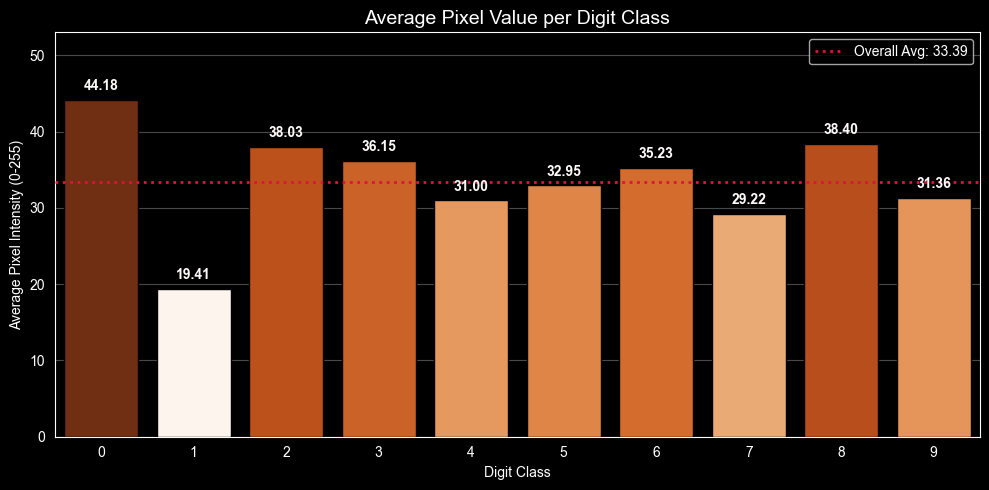

In [3]:
average_values_per_digit = pixel_statistics.average_pixel_values_per_digit(x_data, y_data)
pixel_statistics_output.plot_average_pixel_barplot(average_values_per_digit, average_value)

> NOTE: The `average_value` variable from the previous section is used as a reference line in the bar plot to show how the average pixel value for each digit compares to the overall average pixel value across all images in the dataset. This allows us to easily see which digits are bright and which digits are dark.

The digit '0' is the brightest digit in the dataset, with an average pixel value of around 44. This is followed by the digit '8' and '2' with average pixel values of around 38 each.
The digit '1' is the darkest digit in the dataset, with an average pixel value of around 20. This is followed by the digit '7' with an average pixel value of around 29.

Considering the MNIST dataset is a dataset with a normalized grayscale image, the average pixel intensity values can be contributed only to a small set of factors:
- The structure of the digits: '1' and '7' have a linear structure, which inherently requires fewer drawn pixels. In contrast, '0,' '8,' and '2' have a more complex structure with curves and/or angles, which require more drawn pixels to represent.
- The scaling of the digits: '1' has very few scaling constraints, as it can be written in most shapes and thicknesses without losing its identity. In contrast, '0,' '8,' and '2' have more scaling constraints. There needs to be dead space inside the gaps and around the curves to ensure the digit is still recognizable. This can lead to more drawn pixels and thus a higher average pixel value for these digits.

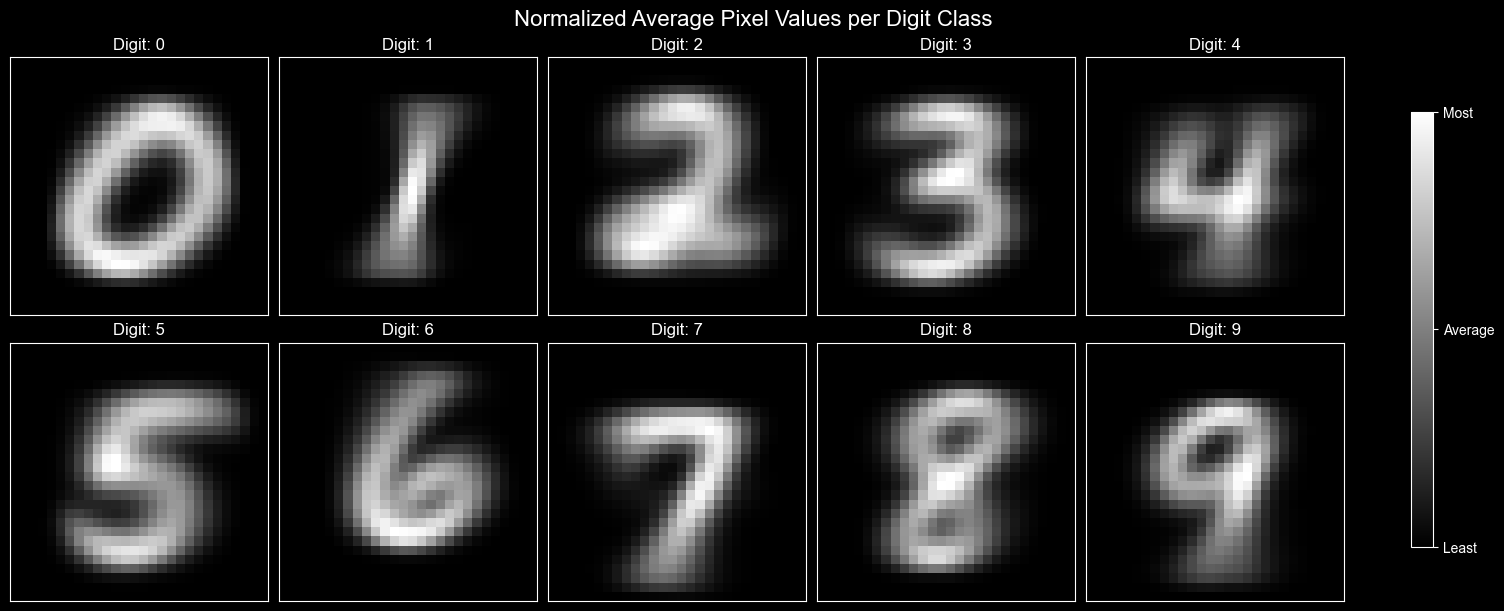

In [4]:
average_digits_dict = pixel_statistics.calculate_average_digit_images(x_data, y_data)

avg_dg_hm_interpolation = "nearest"
pixel_statistics_output.plot_average_digit_heatmaps(average_digits_dict, avg_dg_hm_interpolation)

> NOTE: The `interpolation_method` variable is set to _"nearest"_ by default, however, this can be changed to any of the interpolation methods available to the `matplotlib.pyplot.imshow` function. For convenience, the options are listed below.
>
> _[None, 'none', 'nearest', 'bilinear', 'bicubic', 'spline16', 'spline36', 'hanning', 'hamming', 'hermite', 'kaiser', 'quadric', 'catrom', 'gaussian', 'bessel', 'mitchell', 'sinc', 'lanczos']_

The normalized average pixel values for each digit largely confirm what contributes to the average pixel values for each digit. The '1' and '7' have a clearer "hot spot" in the heatmap, which indicates that the pixel values are more concentrated in a smaller area of the image. Although '0,' '8,' and '2' also have a "hot spot," these are not quite as defined as the '1' and '7,' which indicates that the pixel values are more spread out across the image.

The standard deviation of pixel values for each digit can also be calculated using the `standard_deviation_pixel_values_per_digit` function from the `pixel_statistics` module. This function takes the training and testing pixel data and their corresponding labels as input and returns a dictionary with the standard deviation of pixel values for each digit (0–9) in the dataset. To visualize the standard deviation of pixel values for each digit, we can use the `plot_standard_deviation_heatmap` function from the `pixel_statistics_output` module, which will create a heatmap to show the standard deviation of pixel values for each digit.

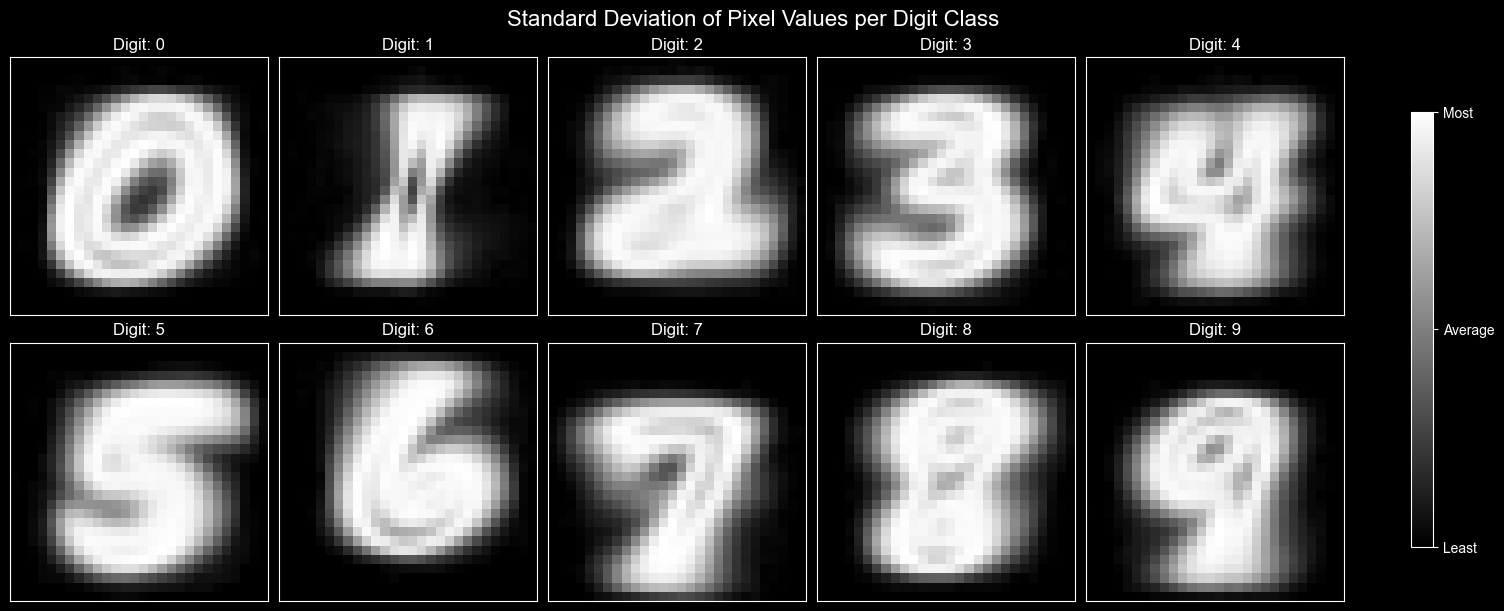

In [5]:
std_dev_digits_dict = pixel_statistics.standard_deviation_pixel_values_per_digit(x_data, y_data)

std_dg_hm_interpolation = "nearest"
pixel_statistics_output.plot_standard_deviation_heatmap(std_dev_digits_dict, std_dg_hm_interpolation)

The standard deviation per class shows a similar pattern to the average pixel values for each digit and further confirms the observations we made about the "hot spots" for each digit. The '1' has a very low standard deviation in the middle. Most other digits have a similar pattern as '1,' but have a higher standard deviation in general. For every digit, the general shape is carved out in the standard deviation, meaning this is where the least variability in pixel values across the dataset is for each digit. The '2' and '5,' however, have a higher standard deviation than any other digit, meaning there is more variability in any given pixel value across the dataset. This could be due to the complexity related to the structure of these digits and how humans choose to deal with that complexity.

## Which pixels are generally "light" (high pixel value) and which pixels are generally "dark" (low pixel value) across the dataset?
To look at the distribution of individual pixel lightness values across the dataset, we can use the `average_pixel_value_across_dataset` function from the `pixel_statistics` module. This function calculates the average pixel value for each pixel position across all images in the dataset, resulting in a 28x28 array of average pixel values. To visualize this distribution, we can use the `plot_average_pixel_value_across_dataset_heatmap` function from the `pixel_statistics_output` module, which will create a heatmap to show the average pixel value for each pixel position across the dataset.

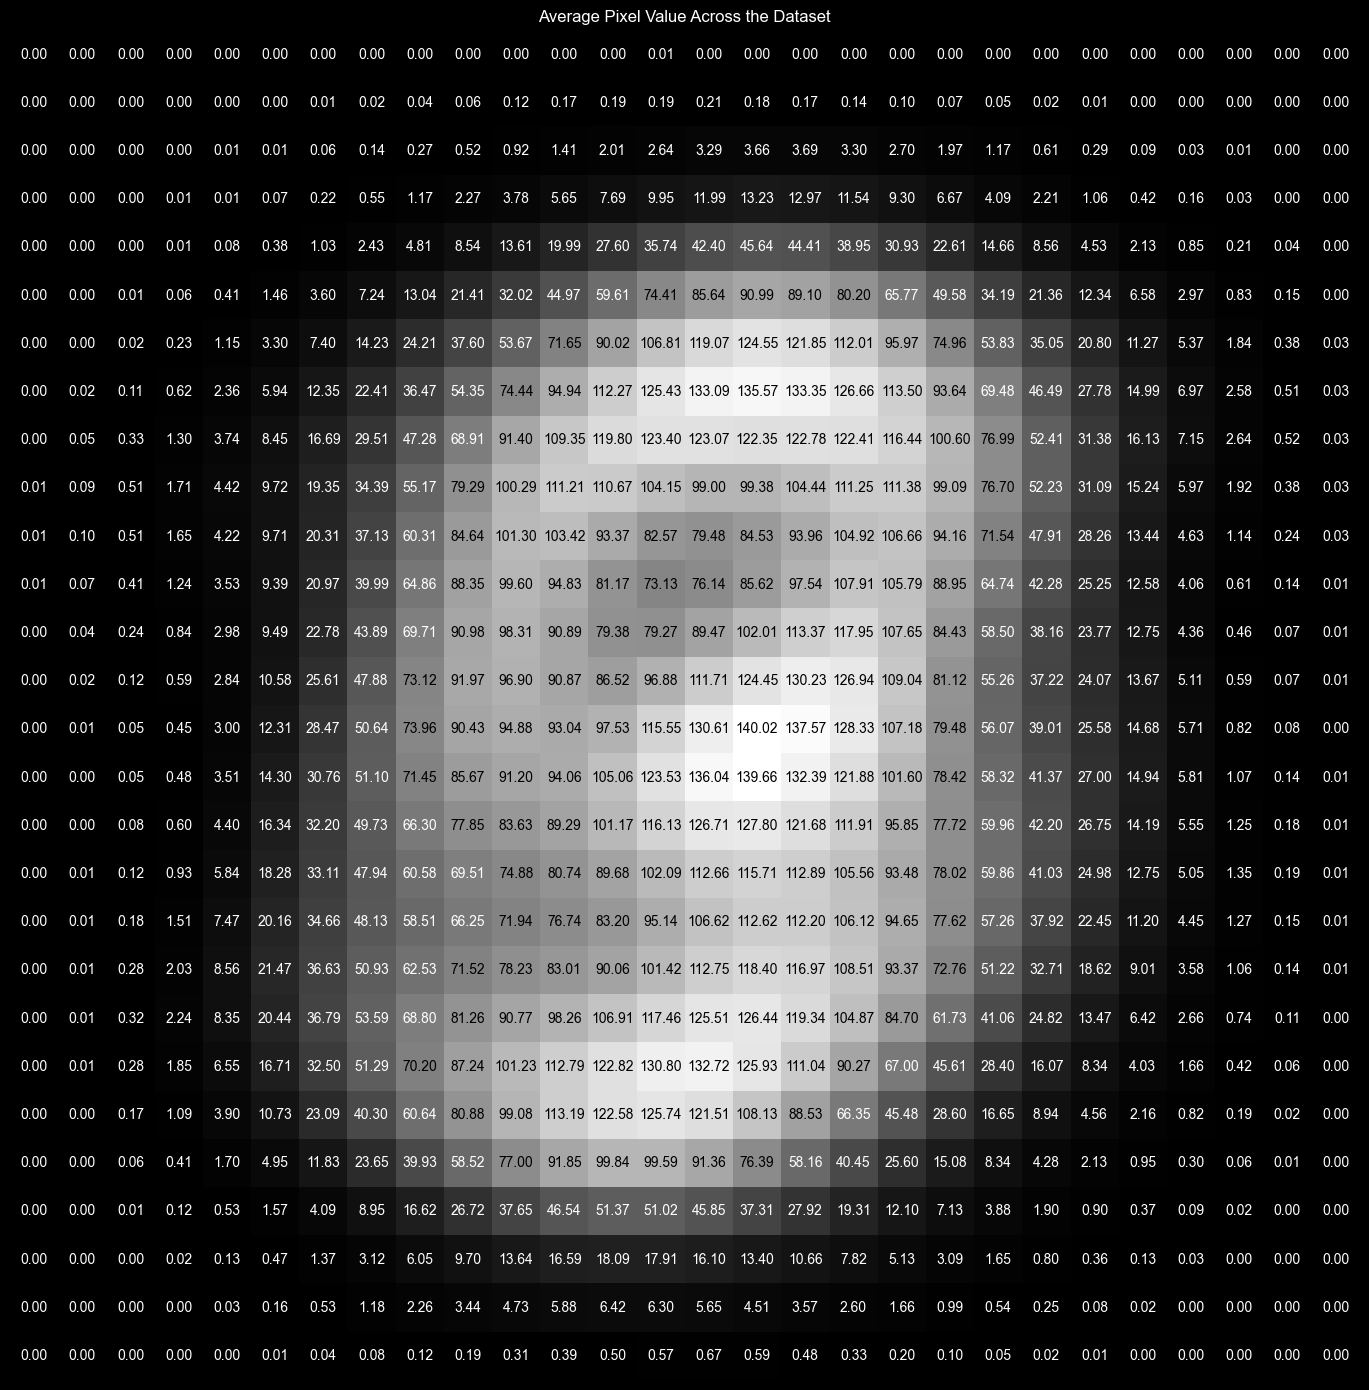

In [6]:
avg_px_ds_interpolation = "nearest"

average_pixel_value_across_dataset = pixel_statistics.average_pixel_value_across_dataset(x_data)
pixel_statistics_output.plot_average_pixel_value_across_dataset_heatmap(average_pixel_value_across_dataset, avg_px_ds_interpolation)

As the image shows, the average pixel value is almost fully dark across the majority of the pixel positions, which is expected, given the handwritten images are centered and the background is black. The lighter pixels show how common each pixel is to be occupied by the digits in the dataset. In general, this shows that the digits far less commonly occupy the pixels around the edges, whilst they more commonly occupy the pixels towards the center of the image. This is expected, as the digits are centered in the images, and thus the pixels towards the center are more likely to be occupied by the digits than the pixels towards the edges. Interestingly, the overlap between all digits reveals a rough outline that resembles the digits '3,' '8,' and '9' more than the other digits, which could be due to the fact these digits have structural overlap with each other.

This, however, isn't enough to determine which pixels are considered light or dark. We can also look at the standard deviation of the pixel values across the dataset to get a better understanding of which pixels are generally light are dark. The `standard_deviation_pixel_value_across_dataset` function from the `pixel_statistics` module calculates the standard deviation of pixel values for each pixel position across all images in the dataset, resulting in a 28x28 array of standard deviation values. To visualize this distribution, we can use the `plot_standard_deviation_pixel_value_across_dataset_heatmap` function from the `pixel_statistics_output` module, which will create a heatmap to show the standard deviation of pixel values for each pixel position across the dataset.

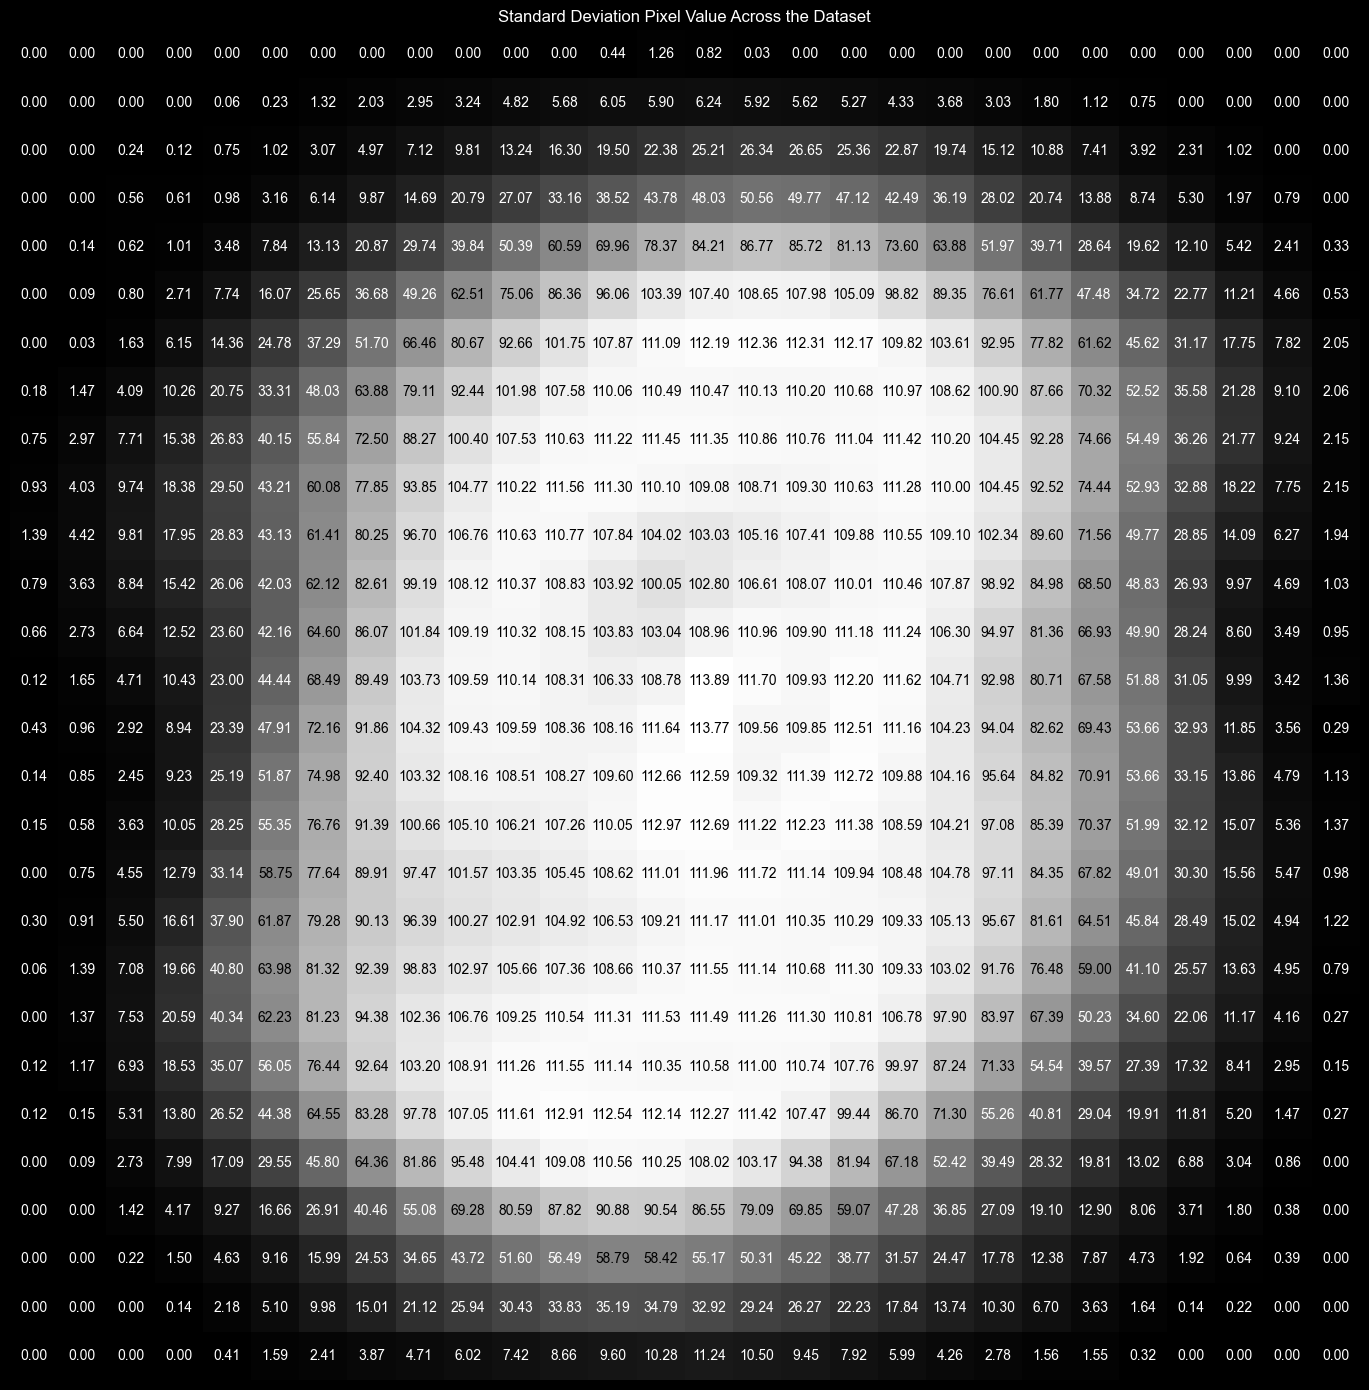

In [7]:
avg_px_std_ds_interpolation = "nearest"

std_dev_pixel_value_across_dataset = pixel_statistics.standard_deviation_pixel_value_across_dataset(x_data)
pixel_statistics_output.plot_standard_deviation_pixel_value_across_dataset_heatmap(std_dev_pixel_value_across_dataset, avg_px_std_ds_interpolation)

As the image shows, the standard deviation creates a bigger and brighter image than the average pixel value across the dataset. This is because the standard deviation captures the variability of pixel values across the dataset, which can highlight areas where there is more variation in pixel values, such as the edges of the digits. Something that jumps out is that, although the average lightness per pixel is higher in the standard deviation than the average pixel value across the dataset, the overall shape remains largely the same. This indicates that the lighter pixels across the dataset are also the pixels that have more variability in their pixel values across the dataset. This makes sense, as these are the pixels that are more likely to be occupied by the digits in the dataset. Another interesting observation is that the lightest pixel in the average pixel value across the dataset is lighter than the lightest pixel in the standard deviation heatmap. This indicates that there are some pixels that are generally light across the dataset but have low variability in their pixel values. This could be because these pixels are consistently occupied by the digits, meaning their standard deviation is slightly lower. The last interesting observation worth mentioning is that the pixels around the center of the image are all around the 100–110 range in the standard deviation heatmap. This indicates hot spots of variability in the dataset, brought on by the shape and structure differences between the digits.

## Conclusion
By analyzing the pixel values of the images in the MNIST dataset, we have gained enough insights to answer the main question of this notebook: **What patterns emerge when we analyze handwritten digits as raw numerical values instead of pictures?** The patterns that emerged from our analysis are as follows:
- The average pixel value across all images in the dataset is relatively low, indicating that the images are generally dark. This is expected, given the handwritten digits are white on a black background.
- Digits carry different average pixel values. This is largely due to the structure and scaling of the digits. Digits with more scaling constraints, for example, tend to have higher average pixel values, as they need more space to be recognizable.
- The concentration of pixel values varies across digits. Where structure and scaling constraints are less strict, "hot spots" are more defined.
- As the digits are centered, the pixels towards the center of the image are generally lighter than the pixels towards the edges of the image.
- The standard deviation of pixel values reveals the structural boundaries and overlap between digits. While the center pixels are consistently bright on average, they also have a high variability in their pixel values across the dataset. This highlights the differences in shape and structure between the digits.